In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Wholesale customers data.csv")

In [4]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
df.shape

(440, 8)

In [6]:
# Checking for null values
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
# No features are irrelevant so we will drop nothing

In [9]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [10]:
## Creating new features:

df["Total_spendings"] = df["Fresh"] + df["Milk"] + df["Grocery"] + df["Frozen"] + df["Detergents_Paper"] + df["Delicassen"]

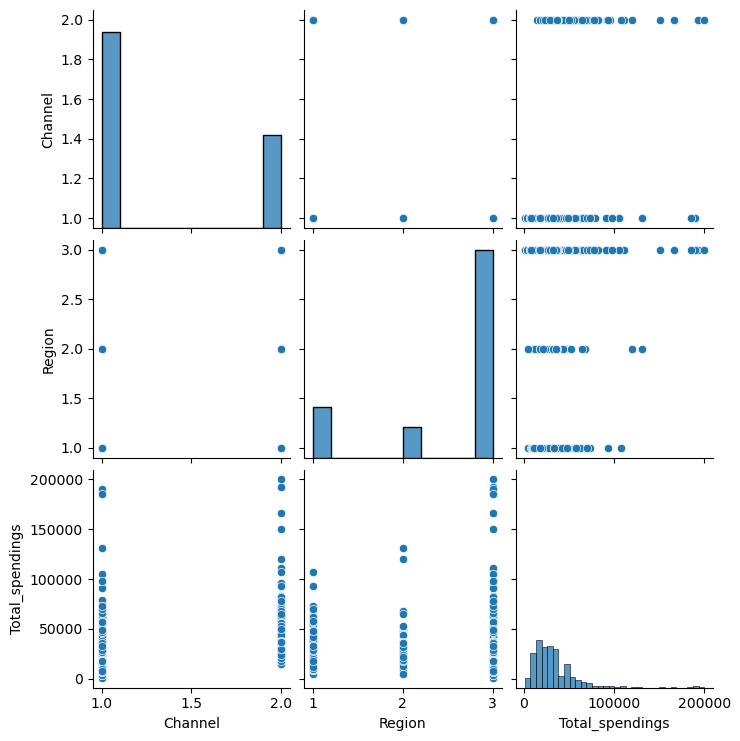

In [13]:
cols = ["Channel", "Region" , "Total_spendings"]

sns.pairplot(df[cols])

### Outliers:
 
1. high fresh buying at channel 1 (we eill keep the buying limit at 10 lakh to maintain the average)
2. uneven correlation of fresh along with grocery

In [14]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen', 'Total_spendings'],
      dtype='object')

In [16]:
cols = ["Channel", "Region", "Total_spendings"]

df_cleaned = df[cols]

In [18]:
corr = df_cleaned.corr(numeric_only= True)
corr

,Channel,Region,Total_spendings
Channel,1.000000,0.062028,0.351177
Region,0.062028,1.000000,0.039039
Total_spendings,0.351177,0.039039,1.000000


<Axes: >

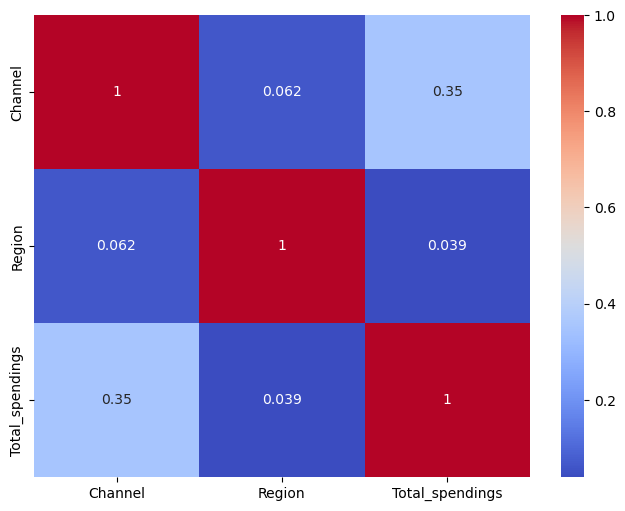

In [19]:
# Correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [25]:
from sklearn.preprocessing import StandardScaler

X = df_cleaned
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

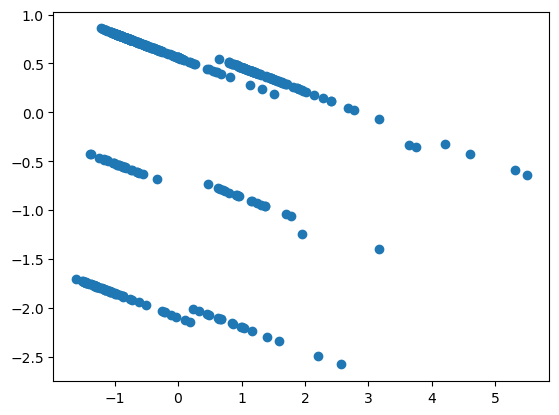

In [30]:
#plot

plt.scatter(X_pca[:,0], X_pca[:,1])

Text(0.5, 0.92, '3d projection')

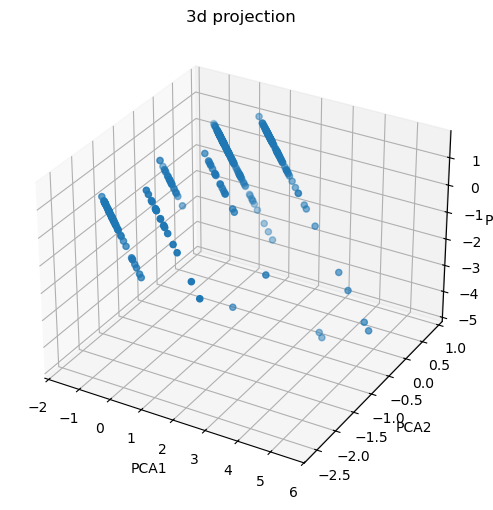

In [31]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

# plot (3D)
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")